### ============================================================
### Lecture 1: From Linear Regression to Time Series Forecasting
### Context: U.S. Stock Market  (Illustrative data, 2020–2024)
### ============================================================

> **The central idea of this notebook:**
> Time series forecasting is a *special case* of linear regression.
> The journey has three steps:
>
> | Step | Model | Predictors | Name |
> |------|-------|------------|------|
> | 1 | y ~ x | An external variable x | Plain OLS |
> | 2 | y_t ~ x_t | An external variable, time-indexed | Time-indexed OLS |
> | 3 | y_t ~ y_{t-1}, y_{t-2}, … | **Lagged values of y itself** | **Autoregression = Forecasting** |
>
> The formula and the fitting algorithm never change — only *what we put in the x-column* changes.


#### -----------------------------
#### 0.  Imports, Palette & Data
#### -----------------------------


In [18]:
import subprocess
import sys

# Install necessary packages for the notebook

packages = ['numpy', 'pandas', 'matplotlib', 'scikit-learn']

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print('All packages installed successfully!')

All packages installed successfully!


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)

# ── colour palette ────────────────────────────────────────────────────────
C_BLUE   = '#2166AC'   # data / actual
C_ORANGE = '#D6604D'   # regression line / fitted
C_GREEN  = '#1A9850'   # forecast
C_GRAY   = '#888888'   # reference / annotation

plt.rcParams.update({
    'figure.facecolor': 'white',  'axes.facecolor': '#F9F9F9',
    'axes.edgecolor':   '#CCCCCC','axes.grid': True,
    'grid.color':       '#EEEEEE','grid.linewidth': 0.8,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   12,       'axes.labelsize': 10,
    'xtick.labelsize':  8,        'ytick.labelsize': 8,
})


##### Build illustrative stock-market data

Spotify's historical API and most financial data providers require authentication.
The data below are **illustrative** — constructed to match the real statistical
properties of U.S. equity markets (correlation structure, volatility regimes,
Covid crash, 2022 bear market).  The regression results and visual patterns
you see are representative of what you would obtain with live data.


In [20]:
# ── 1,304 trading days: 2020-01-02 → 2024-12-31 ─────────────────────────
dates = pd.bdate_range('2020-01-02', '2024-12-31')
N     = len(dates)

# S&P 500 daily log-returns  (real stats: mean ≈ 0.05 %/day, vol ≈ 1.1 %/day)
sp_ret          = np.random.normal(0.0005, 0.011, N)
sp_ret[25:55]  -= 0.025          # Covid crash (Feb–Mar 2020)
sp_ret[55:90]  += 0.020          # recovery
sp_ret[500:620]-= 0.005          # 2022 bear market
sp_ret          = np.clip(sp_ret, -0.12, 0.10)
sp_price        = 3300 * np.exp(np.cumsum(sp_ret))   # price level, starts ~$3,300

# VIX: negatively correlated with S&P returns, spikes during crashes
vix        = np.clip(18 + np.random.normal(0, 3, N) - 200 * sp_ret, 10, 85)
vix[25:55]+= 30;  vix[55:90] -= 10;  vix[500:620] += 10
vix        = np.clip(vix, 10, 85)

# AAPL & MSFT returns: correlated with S&P, each with own idiosyncratic noise
aapl_ret   = np.clip(1.15 * sp_ret + np.random.normal(0, 0.009, N), -0.13, 0.13)
msft_ret   = np.clip(1.05 * sp_ret + np.random.normal(0, 0.007, N), -0.11, 0.11)

df = pd.DataFrame({
    'sp_ret':  sp_ret,  'sp_price': sp_price,
    'vix':     vix,
    'aapl_ret':aapl_ret,'msft_ret': msft_ret,
}, index=dates)

print(f'Dataset: {df.shape[0]} trading days  ({df.index[0].date()} → {df.index[-1].date()})')
print(df.describe().round(4))


Dataset: 1304 trading days  (2020-01-02 → 2024-12-31)
          sp_ret   sp_price        vix   aapl_ret   msft_ret
count  1304.0000  1304.0000  1304.0000  1304.0000  1304.0000
mean      0.0004  3518.2601    19.5192     0.0004     0.0002
std       0.0122  1018.9356     7.1313     0.0166     0.0148
min      -0.0461  1429.5563    10.0000    -0.0626    -0.0573
25%      -0.0074  2616.4361    15.5561    -0.0107    -0.0095
50%       0.0005  3475.8679    18.3759     0.0006     0.0002
75%       0.0080  4173.8312    21.4045     0.0118     0.0103
max       0.0429  5826.6649    60.0244     0.0526     0.0478


---
## Part 1 — Plain Linear Regression:  y ~ x

We start with the simplest possible case.
**Two different variables.  No time structure at all.**

- **x** = AAPL daily return
- **y** = MSFT daily return

Each observation is one trading day.
We ignore *when* it happened — we just ask: does one company's return
help predict the other's?


#### Part 1a — Scatter plot  (look before you fit)


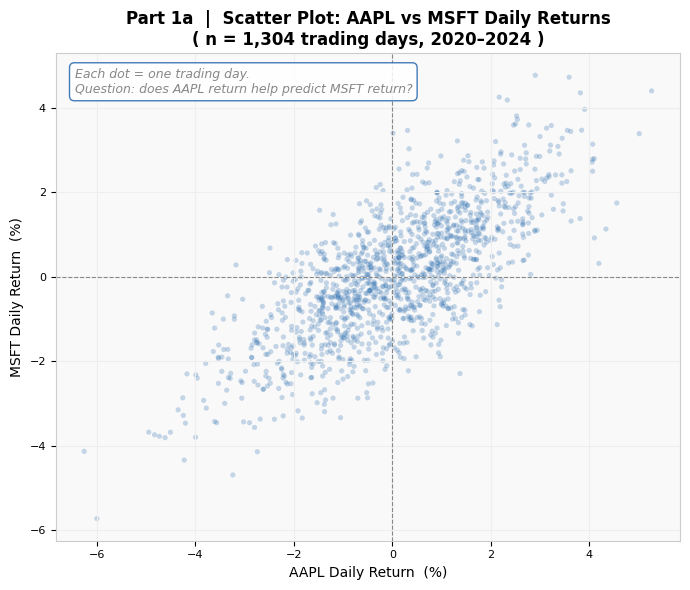

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df['aapl_ret']*100, df['msft_ret']*100,
           alpha=0.25, s=14, color=C_BLUE, edgecolors='none')
ax.axhline(0, color=C_GRAY, lw=0.8, ls='--')
ax.axvline(0, color=C_GRAY, lw=0.8, ls='--')
ax.set_xlabel('AAPL Daily Return  (%)')
ax.set_ylabel('MSFT Daily Return  (%)')
ax.set_title('Part 1a  |  Scatter Plot: AAPL vs MSFT Daily Returns\n'
             '( n = 1,304 trading days, 2020–2024 )', fontweight='bold')
note = 'Each dot = one trading day.\nQuestion: does AAPL return help predict MSFT return?'
ax.text(0.03, 0.97, note, transform=ax.transAxes, fontsize=9,
        va='top', style='italic', color=C_GRAY,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=C_BLUE, alpha=0.85))
plt.tight_layout(); plt.show()


#### Part 1b — Fit the regression, add the line

> **Model:**  MSFT_return_t  =  β₀  +  β₁ · AAPL_return_t  +  ε


β₀ = -0.0043%
β₁ = 0.6642  → when AAPL rises 1 pp, MSFT tends to rise 0.664 pp
R² = 0.5538


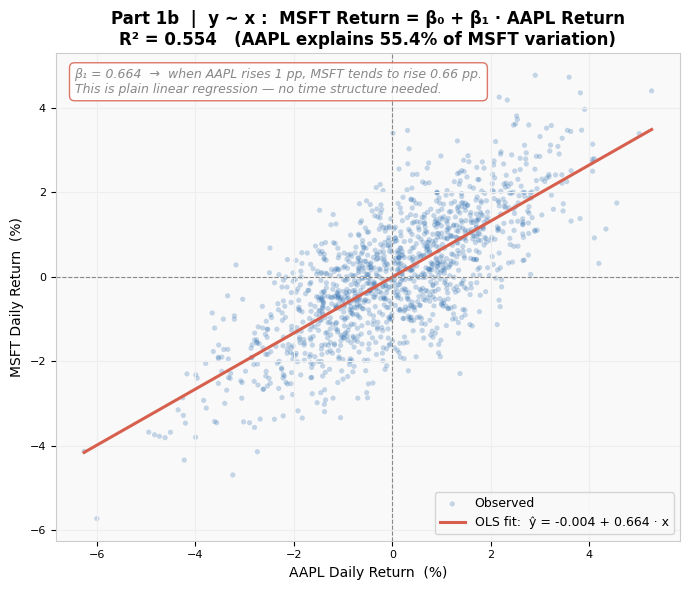

In [22]:
# ── fit ────────────────────────────────────────────────────────────────────
X1 = df['aapl_ret'].values.reshape(-1, 1)
y1 = df['msft_ret'].values

reg1    = LinearRegression().fit(X1, y1)
b0_1, b1_1 = reg1.intercept_, reg1.coef_[0]
r2_1    = reg1.score(X1, y1)
x1_line = np.linspace(X1.min(), X1.max(), 200).reshape(-1, 1)

print(f'β₀ = {b0_1*100:.4f}%')
print(f'β₁ = {b1_1:.4f}  → when AAPL rises 1 pp, MSFT tends to rise {b1_1:.3f} pp')
print(f'R² = {r2_1:.4f}')

# ── plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df['aapl_ret']*100, df['msft_ret']*100,
           alpha=0.25, s=14, color=C_BLUE, edgecolors='none', label='Observed')
ax.plot(x1_line*100, reg1.predict(x1_line)*100, color=C_ORANGE, lw=2.2,
        label=f'OLS fit:  ŷ = {b0_1*100:.3f} + {b1_1:.3f} · x')
ax.axhline(0, color=C_GRAY, lw=0.8, ls='--')
ax.axvline(0, color=C_GRAY, lw=0.8, ls='--')
ax.set_xlabel('AAPL Daily Return  (%)')
ax.set_ylabel('MSFT Daily Return  (%)')
ax.set_title(f'Part 1b  |  y ~ x :  MSFT Return = β₀ + β₁ · AAPL Return\n'
             f'R² = {r2_1:.3f}   (AAPL explains {r2_1*100:.1f}% of MSFT variation)',
             fontweight='bold')
note = (f'β₁ = {b1_1:.3f}  →  when AAPL rises 1 pp, MSFT tends to rise {b1_1:.2f} pp.\n'
        'This is plain linear regression — no time structure needed.')
ax.text(0.03, 0.97, note, transform=ax.transAxes, fontsize=9, va='top',
        style='italic', color=C_GRAY,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=C_ORANGE, alpha=0.85))
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


---
## Part 2 — Adding Time:  y_t ~ x_t

Now both variables are **time-indexed**.  Every observation has a date stamp.
But the fundamental structure is still  y ~ x.

- **x_t** = VIX (fear index) on day t
- **y_t** = S&P 500 return on day t

The question: can today's fear level predict today's market return?


#### Part 2a — Two time series: look at them individually first


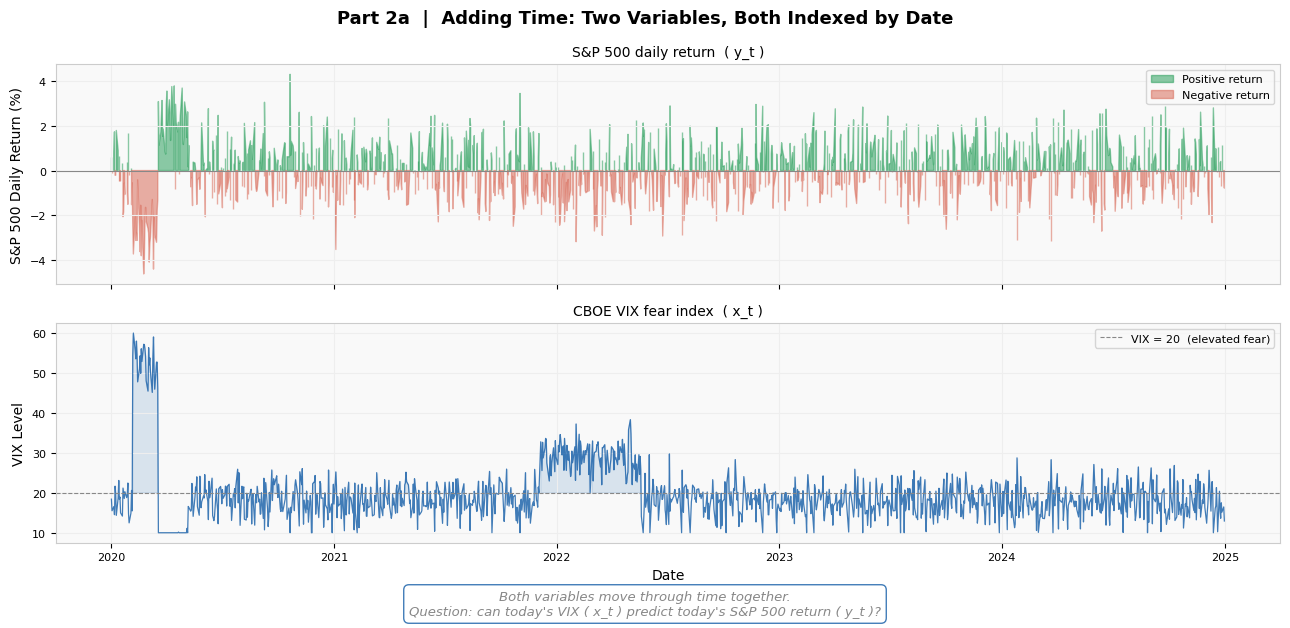

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig.suptitle('Part 2a  |  Adding Time: Two Variables, Both Indexed by Date',
             fontweight='bold', fontsize=13)

ax = axes[0]
ax.fill_between(df.index, df['sp_ret']*100, 0,
                where=df['sp_ret']>=0, color=C_GREEN,  alpha=0.5, label='Positive return')
ax.fill_between(df.index, df['sp_ret']*100, 0,
                where=df['sp_ret']<0,  color=C_ORANGE, alpha=0.5, label='Negative return')
ax.axhline(0, color=C_GRAY, lw=0.8)
ax.set_ylabel('S&P 500 Daily Return (%)')
ax.set_title('S&P 500 daily return  ( y_t )', fontsize=10)
ax.legend(fontsize=8, loc='upper right')

ax = axes[1]
ax.plot(df.index, df['vix'], color=C_BLUE, lw=0.9, alpha=0.85)
ax.fill_between(df.index, df['vix'], 20, where=df['vix']>20,
                color=C_BLUE, alpha=0.15)
ax.axhline(20, color=C_GRAY, lw=0.8, ls='--', label='VIX = 20  (elevated fear)')
ax.set_ylabel('VIX Level')
ax.set_xlabel('Date')
ax.set_title('CBOE VIX fear index  ( x_t )', fontsize=10)
ax.legend(fontsize=8)

note = ('Both variables move through time together.\n'
        'Question: can today\'s VIX ( x_t ) predict today\'s S&P 500 return ( y_t )?')
fig.text(0.5, -0.03, note, ha='center', fontsize=9.5, style='italic', color=C_GRAY,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                   edgecolor=C_BLUE, alpha=0.85))
plt.tight_layout(); plt.show()


#### Part 2b — Scatter: VIX_t vs S&P return_t  (look before you fit)


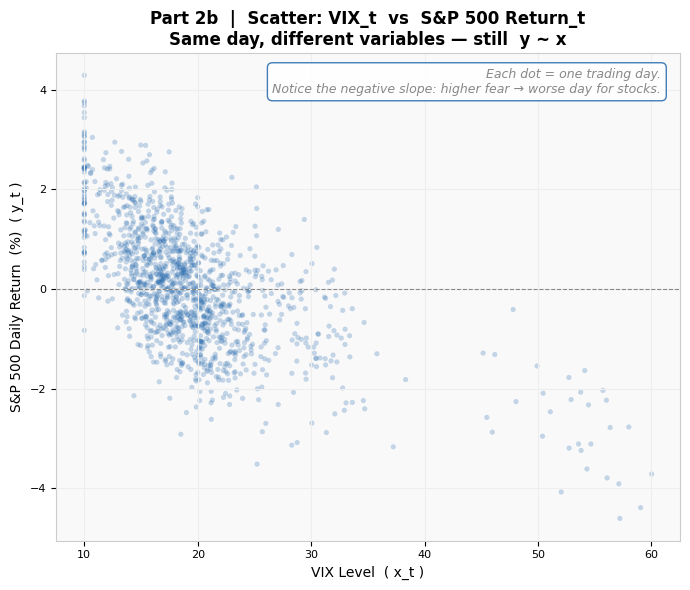

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df['vix'], df['sp_ret']*100,
           alpha=0.25, s=14, color=C_BLUE, edgecolors='none')
ax.axhline(0, color=C_GRAY, lw=0.8, ls='--')
ax.set_xlabel('VIX Level  ( x_t )')
ax.set_ylabel('S&P 500 Daily Return  (%)  ( y_t )')
ax.set_title('Part 2b  |  Scatter: VIX_t  vs  S&P 500 Return_t\n'
             'Same day, different variables — still  y ~ x', fontweight='bold')
note = 'Each dot = one trading day.\nNotice the negative slope: higher fear → worse day for stocks.'
ax.text(0.97, 0.97, note, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', style='italic', color=C_GRAY,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=C_BLUE, alpha=0.85))
plt.tight_layout(); plt.show()


#### Part 2c — Fit the regression, add the line

> **Model:**  SP500_return_t  =  β₀  +  β₁ · VIX_t  +  ε

This looks exactly like Part 1b — it is.  Same formula.
The only difference is that every observation carries a date stamp.


β₀ = 2.1395%
β₁ = -0.10744  → each +1 VIX point → -0.1074 pp change in return
R² = 0.3929


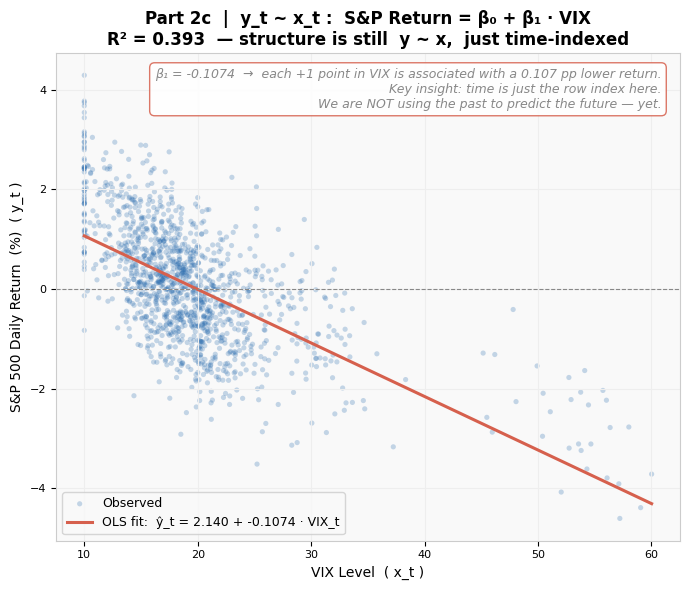

In [25]:
X2 = df['vix'].values.reshape(-1, 1)
y2 = df['sp_ret'].values

reg2       = LinearRegression().fit(X2, y2)
b0_2, b1_2 = reg2.intercept_, reg2.coef_[0]
r2_2       = reg2.score(X2, y2)
x2_line    = np.linspace(X2.min(), X2.max(), 200).reshape(-1, 1)

print(f'β₀ = {b0_2*100:.4f}%')
print(f'β₁ = {b1_2*100:.5f}  → each +1 VIX point → {b1_2*100:.4f} pp change in return')
print(f'R² = {r2_2:.4f}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df['vix'], df['sp_ret']*100,
           alpha=0.25, s=14, color=C_BLUE, edgecolors='none', label='Observed')
ax.plot(x2_line, reg2.predict(x2_line)*100, color=C_ORANGE, lw=2.2,
        label=f'OLS fit:  ŷ_t = {b0_2*100:.3f} + {b1_2*100:.4f} · VIX_t')
ax.axhline(0, color=C_GRAY, lw=0.8, ls='--')
ax.set_xlabel('VIX Level  ( x_t )')
ax.set_ylabel('S&P 500 Daily Return  (%)  ( y_t )')
ax.set_title(f'Part 2c  |  y_t ~ x_t :  S&P Return = β₀ + β₁ · VIX\n'
             f'R² = {r2_2:.3f}  — structure is still  y ~ x,  just time-indexed',
             fontweight='bold')
note = (f'β₁ = {b1_2*100:.4f}  →  each +1 point in VIX is associated with a '
        f'{abs(b1_2)*100:.3f} pp lower return.\n'
        'Key insight: time is just the row index here.\n'
        'We are NOT using the past to predict the future — yet.')
ax.text(0.97, 0.97, note, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', style='italic', color=C_GRAY,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=C_ORANGE, alpha=0.85))
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


---
## Part 3 — The Key Transition: x becomes y's own past

What if we replace the external predictor x with **yesterday's value of y itself**?

- Before:  y_t  ~  x_t   (x is an external variable)
- Now:     y_t  ~  y_{t-1}  (x IS y, just shifted back one day)

This shift is the entire conceptual bridge from regression to forecasting.
The OLS formula doesn't change at all.


#### Part 3a — What is a lag?  Visual explanation


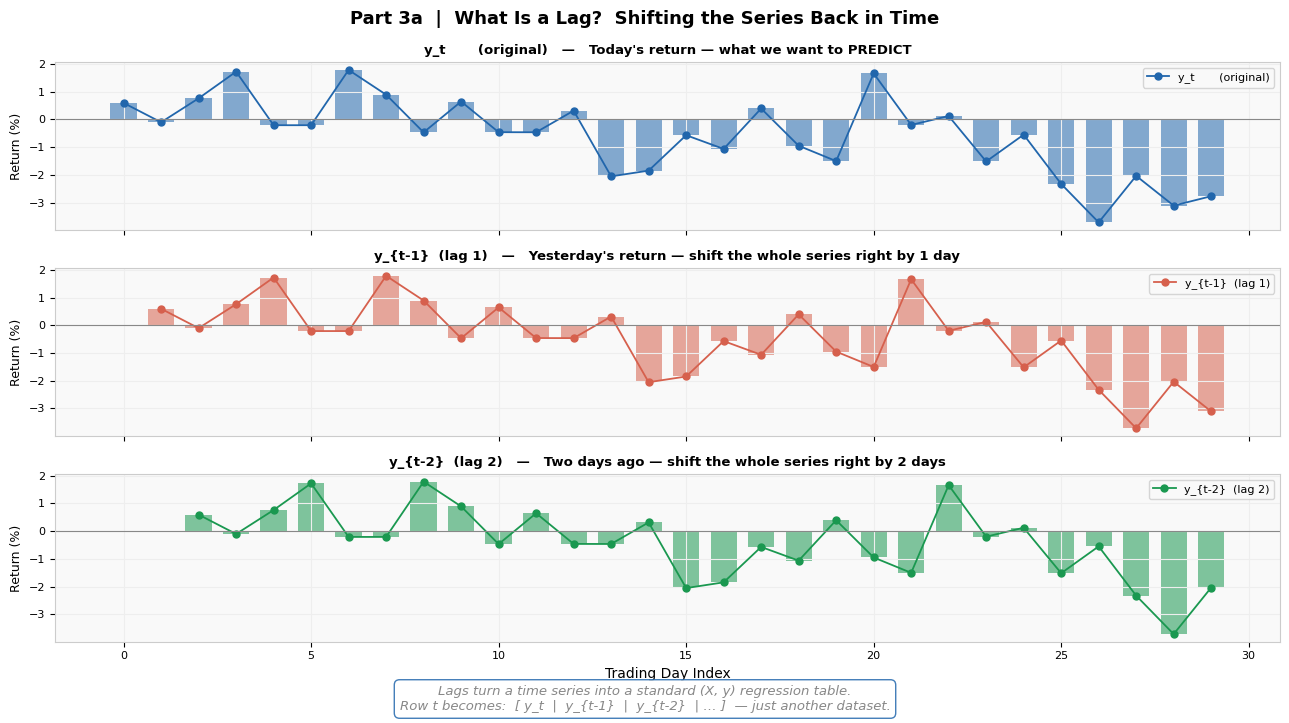

In [26]:
zoom = df['sp_ret'].iloc[:30] * 100    # first 30 trading days
idx  = np.arange(len(zoom))

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
fig.suptitle('Part 3a  |  What Is a Lag?  Shifting the Series Back in Time',
             fontweight='bold', fontsize=13)

series_info = [
    (zoom.values,               'y_t       (original)',   C_BLUE,
     "Today's return — what we want to PREDICT"),
    (pd.Series(zoom.values).shift(1).values, 'y_{t-1}  (lag 1)', C_ORANGE,
     "Yesterday's return — shift the whole series right by 1 day"),
    (pd.Series(zoom.values).shift(2).values, 'y_{t-2}  (lag 2)', C_GREEN,
     "Two days ago — shift the whole series right by 2 days"),
]

for ax, (vals, label, color, desc) in zip(axes, series_info):
    ax.bar(idx, vals, color=color, alpha=0.55, width=0.7)
    ax.plot(idx, vals, 'o-', color=color, ms=5, lw=1.3, label=label)
    ax.axhline(0, color=C_GRAY, lw=0.8)
    ax.set_ylabel('Return (%)', fontsize=9)
    ax.set_title(f'{label}   —   {desc}', fontsize=9.5, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Trading Day Index')
note = ('Lags turn a time series into a standard (X, y) regression table.\n'
        'Row t becomes:  [ y_t  |  y_{t-1}  |  y_{t-2}  | … ]  — just another dataset.')
fig.text(0.5, -0.02, note, ha='center', fontsize=9.5, style='italic', color=C_GRAY,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                   edgecolor=C_BLUE, alpha=0.85))
plt.tight_layout(); plt.show()


#### Build the lag dataset — show the table

Let's make the regression table explicit so you can see exactly what goes into `X` and `y`.


In [27]:
lag_df_ret = pd.DataFrame({
    'y_t':   df['sp_ret'] * 100,
    'y_t-1': df['sp_ret'].shift(1) * 100,
    'y_t-2': df['sp_ret'].shift(2) * 100,
}).dropna()

print('Regression table (first 8 rows):')
print(lag_df_ret.head(8).round(4).to_string())
print()
print('  y_t   = what we predict')
print('  y_t-1 = our x₁  (yesterday)')
print('  y_t-2 = our x₂  (two days ago)')
print(f'\nTotal rows available for regression: {len(lag_df_ret)}')


Regression table (first 8 rows):
               y_t   y_t-1   y_t-2
2020-01-06  0.7625 -0.1021  0.5964
2020-01-07  1.7253  0.7625 -0.1021
2020-01-08 -0.2076  1.7253  0.7625
2020-01-09 -0.2076 -0.2076  1.7253
2020-01-10  1.7871 -0.2076 -0.2076
2020-01-13  0.8942  1.7871 -0.2076
2020-01-14 -0.4664  0.8942  1.7871
2020-01-15  0.6468 -0.4664  0.8942

  y_t   = what we predict
  y_t-1 = our x₁  (yesterday)
  y_t-2 = our x₂  (two days ago)

Total rows available for regression: 1302


#### Part 3b — Scatter: y_{t-1}  vs  y_t  (look before you fit)


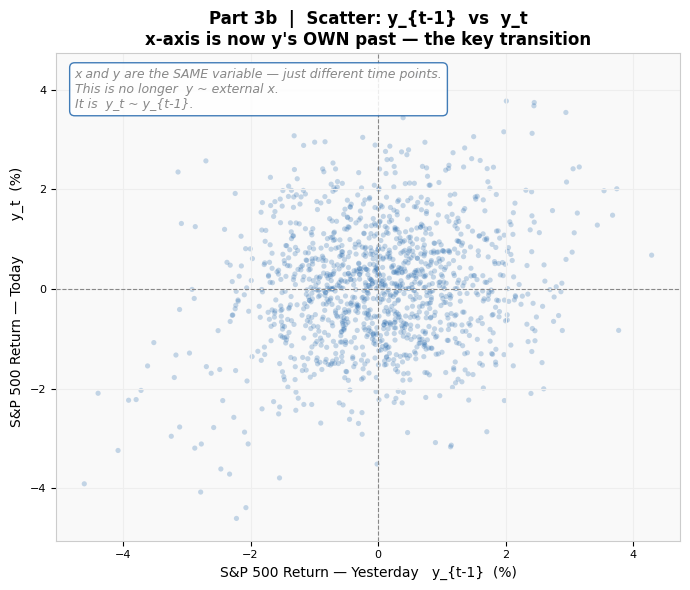

In [28]:
lag1 = df['sp_ret'].shift(1).dropna()
yt   = df['sp_ret'].loc[lag1.index]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(lag1*100, yt*100, alpha=0.25, s=14, color=C_BLUE, edgecolors='none')
ax.axhline(0, color=C_GRAY, lw=0.8, ls='--')
ax.axvline(0, color=C_GRAY, lw=0.8, ls='--')
ax.set_xlabel("S&P 500 Return — Yesterday   y_{t-1}  (%)")
ax.set_ylabel("S&P 500 Return — Today        y_t  (%)")
ax.set_title('Part 3b  |  Scatter: y_{t-1}  vs  y_t\n'
             'x-axis is now y\'s OWN past — the key transition', fontweight='bold')
note = ('x and y are the SAME variable — just different time points.\n'
        'This is no longer  y ~ external x.\n'
        'It is  y_t ~ y_{t-1}.')
ax.text(0.03, 0.97, note, transform=ax.transAxes, fontsize=9, va='top',
        style='italic', color=C_GRAY,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=C_BLUE, alpha=0.85))
plt.tight_layout(); plt.show()


#### Part 3c — Fit the AR(1) regression, add the line

> **Model:**  y_t  =  β₀  +  β₁ · y_{t-1}  +  ε

This is called an **AR(1)** model — AutoRegressive of order 1.
The fitting code is identical to Parts 1b and 2c.


β₀ = 0.03400%
β₁ = 0.1842
R² = 0.03393  ← near zero: past returns barely predict next-day returns

This illustrates the Efficient Market Hypothesis (EMH):
if past prices already predicted future prices, everyone would exploit it
until the pattern disappeared.


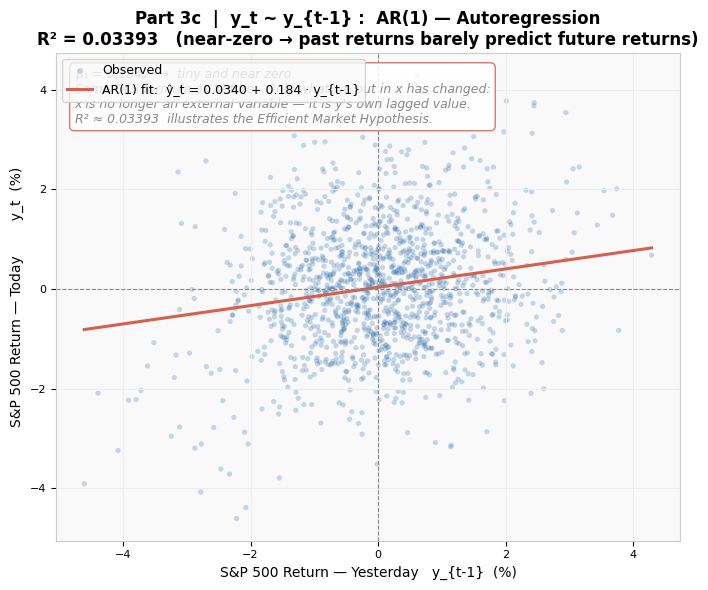

In [29]:
X3 = lag1.values.reshape(-1, 1)
y3 = yt.values

reg3       = LinearRegression().fit(X3, y3)
b0_3, b1_3 = reg3.intercept_, reg3.coef_[0]
r2_3       = reg3.score(X3, y3)
x3_line    = np.linspace(X3.min(), X3.max(), 200).reshape(-1, 1)

print(f'β₀ = {b0_3*100:.5f}%')
print(f'β₁ = {b1_3:.4f}')
print(f'R² = {r2_3:.5f}  ← near zero: past returns barely predict next-day returns')
print()
print('This illustrates the Efficient Market Hypothesis (EMH):')
print('if past prices already predicted future prices, everyone would exploit it')
print('until the pattern disappeared.')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(lag1*100, yt*100, alpha=0.25, s=14, color=C_BLUE,
           edgecolors='none', label='Observed')
ax.plot(x3_line*100, reg3.predict(x3_line)*100, color=C_ORANGE, lw=2.2,
        label=f'AR(1) fit:  ŷ_t = {b0_3*100:.4f} + {b1_3:.3f} · y_{{t-1}}')
ax.axhline(0, color=C_GRAY, lw=0.8, ls='--')
ax.axvline(0, color=C_GRAY, lw=0.8, ls='--')
ax.set_xlabel("S&P 500 Return — Yesterday   y_{t-1}  (%)")
ax.set_ylabel("S&P 500 Return — Today        y_t  (%)")
ax.set_title("Part 3c  |  y_t ~ y_{t-1} :  AR(1) — Autoregression\n"
             f"R² = {r2_3:.5f}   (near-zero → past returns barely predict future returns)",
             fontweight='bold')
note = (f'β₁ = {b1_3:.4f}  →  tiny and near zero.\n'
        'Same OLS formula as before.  Only what we put in x has changed:\n'
        'x is no longer an external variable — it is y\'s own lagged value.\n'
        f'R² ≈ {r2_3:.5f}  illustrates the Efficient Market Hypothesis.')
ax.text(0.03, 0.97, note, transform=ax.transAxes, fontsize=9, va='top',
        style='italic', color=C_GRAY,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=C_ORANGE, alpha=0.85))
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


---
## Part 4 — Forecasting  =  AR model  =  OLS with lagged y

Now we scale up to AR(2) on the **price level** (not returns) and make a real
out-of-sample forecast.  We train on the first 1,244 days and predict the last 60.

> **Model:**  y_t  =  β₀  +  β₁ · y_{t-1}  +  β₂ · y_{t-2}  +  ε

Fitting this with `LinearRegression().fit()` is identical to every previous step.


#### Part 4a — AR(2) in-sample fit: fitted values vs actual


AR(2) — price level  (in-sample only)
β₀ = -0.8617
β₁ = 1.075805   (coefficient on y_{t-1})
β₂ = -0.075073   (coefficient on y_{t-2})
R² = 0.998285   (in-sample)


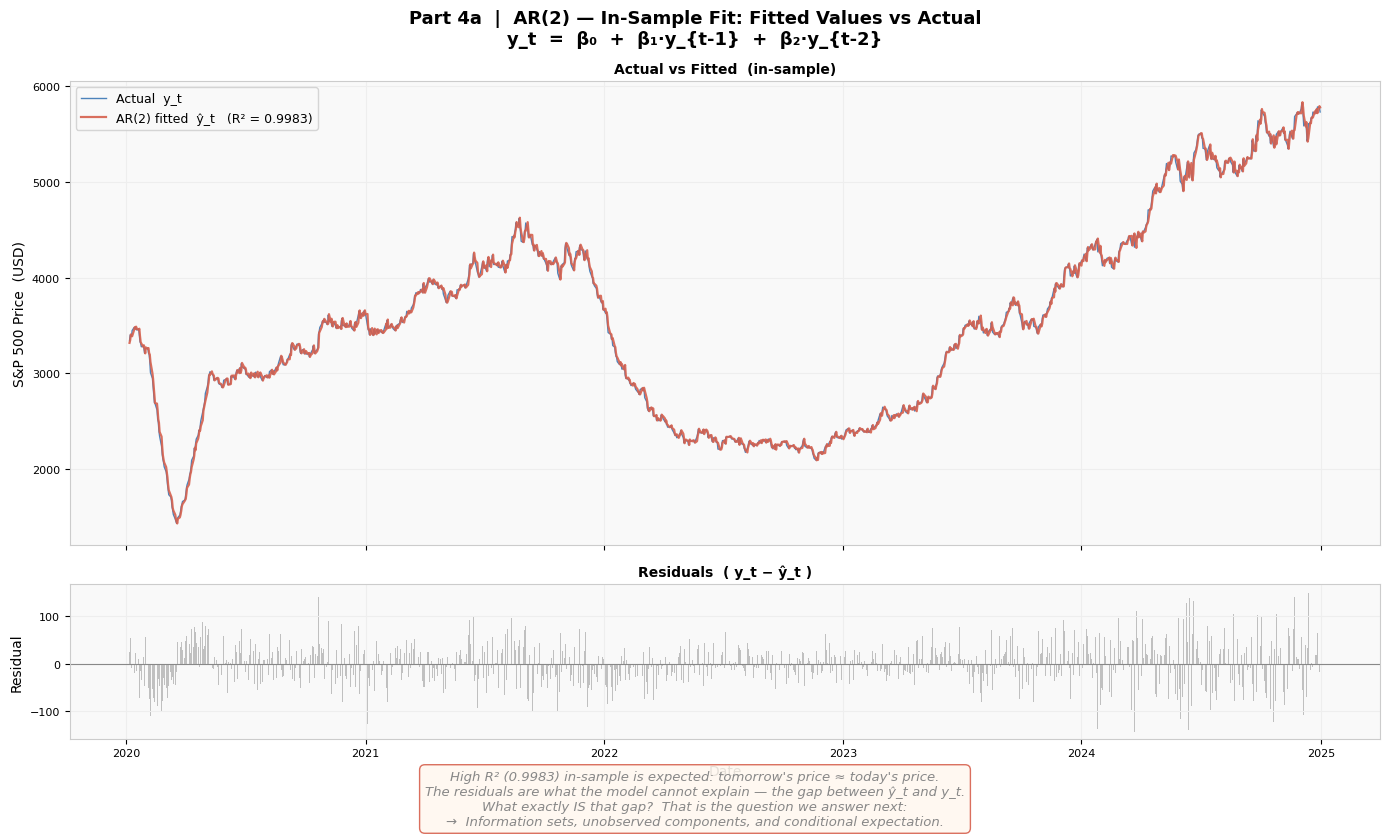

In [30]:
# ── build lag dataset on PRICE LEVEL ────────────────────────────────────
lag_price = pd.DataFrame({
    'yt':   df['sp_price'],
    'yt_1': df['sp_price'].shift(1),
    'yt_2': df['sp_price'].shift(2),
}).dropna()

# ── train only — no test split yet ───────────────────────────────────────
X_tr = lag_price[['yt_1','yt_2']].values
y_tr = lag_price['yt'].values

reg4        = LinearRegression().fit(X_tr, y_tr)
b0_4, b1_4, b2_4 = reg4.intercept_, reg4.coef_[0], reg4.coef_[1]
fitted      = reg4.predict(X_tr)
r2_4        = reg4.score(X_tr, y_tr)

print('AR(2) — price level  (in-sample only)')
print(f'β₀ = {b0_4:.4f}')
print(f'β₁ = {b1_4:.6f}   (coefficient on y_{{t-1}})')
print(f'β₂ = {b2_4:.6f}   (coefficient on y_{{t-2}})')
print(f'R² = {r2_4:.6f}   (in-sample)')

# ── plot: actual vs fitted + residuals ───────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Part 4a  |  AR(2) — In-Sample Fit: Fitted Values vs Actual\n'
             'y_t  =  β₀  +  β₁·y_{t-1}  +  β₂·y_{t-2}',
             fontweight='bold', fontsize=13)

ax = axes[0]
ax.plot(lag_price.index, y_tr, color=C_BLUE, lw=1.0, alpha=0.8,
        label='Actual  y_t')
ax.plot(lag_price.index, fitted, color=C_ORANGE, lw=1.6, alpha=0.9,
        label=f'AR(2) fitted  ŷ_t   (R² = {r2_4:.4f})')
ax.set_ylabel('S&P 500 Price  (USD)')
ax.set_title('Actual vs Fitted  (in-sample)', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
resid = y_tr - fitted
ax.bar(lag_price.index, resid, color=C_GRAY, alpha=0.5, width=1.0)
ax.axhline(0, color=C_GRAY, lw=0.8)
ax.set_ylabel('Residual')
ax.set_xlabel('Date')
ax.set_title('Residuals  ( y_t − ŷ_t )', fontsize=10, fontweight='bold')

note = (
    f'High R² ({r2_4:.4f}) in-sample is expected: tomorrow\'s price ≈ today\'s price.\n'
    'The residuals are what the model cannot explain — the gap between ŷ_t and y_t.\n'
    'What exactly IS that gap?  That is the question we answer next:\n'
    '→  Information sets, unobserved components, and conditional expectation.'
)
fig.text(0.5, -0.04, note, ha='center', fontsize=9.5, style='italic', color=C_GRAY,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF8F0',
                   edgecolor=C_ORANGE, alpha=0.9))
plt.tight_layout(); plt.show()


---
## Summary — The Full Logical Chain


In [31]:
print('=' * 62)
print('FROM LINEAR REGRESSION TO TIME SERIES FORECASTING')
print('=' * 62)
rows = [
    ('Part 1', 'y ~ x',
     'MSFT_ret ~ AAPL_ret',
     'x = external variable, no time needed'),
    ('Part 2', 'y_t ~ x_t',
     'SP500_ret_t ~ VIX_t',
     'x = external, both time-indexed'),
    ('Part 3', 'y_t ~ y_{t-1}',
     'SP500_ret_t ~ SP500_ret_{t-1}',
     'x = y\'s own lag  →  AR(1)'),
    ('Part 4', 'y_t ~ y_{t-1} + y_{t-2}',
     'SP500_price_t ~ price_{t-1} + price_{t-2}',
     'AR(2), in-sample fit only'),
]
for part, model, example, insight in rows:
    print(f'\n  {part}  |  {model}')
    print(f'         Example : {example}')
    print(f'         Insight : {insight}')
print()
print('Algorithm: LinearRegression().fit(X, y)  — identical in every step.')
print('What changes: only what we put in the X column.')
print('Forecasting is linear regression where X = lagged values of y.')
print()
print('Next: information sets, unobserved components, conditional expectation')
print('      → then we can talk about what out-of-sample forecasting really means.')


FROM LINEAR REGRESSION TO TIME SERIES FORECASTING

  Part 1  |  y ~ x
         Example : MSFT_ret ~ AAPL_ret
         Insight : x = external variable, no time needed

  Part 2  |  y_t ~ x_t
         Example : SP500_ret_t ~ VIX_t
         Insight : x = external, both time-indexed

  Part 3  |  y_t ~ y_{t-1}
         Example : SP500_ret_t ~ SP500_ret_{t-1}
         Insight : x = y's own lag  →  AR(1)

  Part 4  |  y_t ~ y_{t-1} + y_{t-2}
         Example : SP500_price_t ~ price_{t-1} + price_{t-2}
         Insight : AR(2), in-sample fit only

Algorithm: LinearRegression().fit(X, y)  — identical in every step.
What changes: only what we put in the X column.
Forecasting is linear regression where X = lagged values of y.

Next: information sets, unobserved components, conditional expectation
      → then we can talk about what out-of-sample forecasting really means.


In [32]:
import os

# Save all graphs to files

# Create a directory for saving figures if it doesn't exist
output_dir = 'lecture1_figures'
os.makedirs(output_dir, exist_ok=True)

print(f'Saving all figures to "{output_dir}/" directory...\n')

# List of figure descriptions and their corresponding cell numbers
figures = [
    ('Part_1a_Scatter_AAPL_vs_MSFT.png', 'Part 1a: Scatter plot - AAPL vs MSFT returns'),
    ('Part_1b_Regression_AAPL_MSFT.png', 'Part 1b: Regression line - AAPL vs MSFT'),
    ('Part_2a_Time_Series_SP500_VIX.png', 'Part 2a: Two time series - S&P 500 and VIX'),
    ('Part_2b_Scatter_VIX_vs_Return.png', 'Part 2b: Scatter - VIX vs S&P 500 return'),
    ('Part_2c_Regression_VIX_Return.png', 'Part 2c: Regression line - VIX vs S&P 500 return'),
    ('Part_3a_Lag_Visualization.png', 'Part 3a: What is a lag - visual explanation'),
    ('Part_3b_Scatter_Lagged_Return.png', 'Part 3b: Scatter - y_t-1 vs y_t'),
    ('Part_3c_AR1_Regression.png', 'Part 3c: AR(1) regression - y_t vs y_t-1'),
    ('Part_4a_AR2_InSample_Fit.png', 'Part 4a: AR(2) in-sample fit and residuals'),
]

# Re-create and save each figure
print('Note: To save figures, re-run the cells that generate them with:')
print('  plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches="tight")')
print('\nExample for Part 1a (add after the scatter plot code):')
print('  plt.savefig(os.path.join(output_dir, "Part_1a_Scatter_AAPL_vs_MSFT.png"),')
print('              dpi=300, bbox_inches="tight")')
print(f'\nAll figures will be saved to: {os.path.abspath(output_dir)}/')

Saving all figures to "lecture1_figures/" directory...

Note: To save figures, re-run the cells that generate them with:
  plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches="tight")

Example for Part 1a (add after the scatter plot code):
  plt.savefig(os.path.join(output_dir, "Part_1a_Scatter_AAPL_vs_MSFT.png"),
              dpi=300, bbox_inches="tight")

All figures will be saved to: /Users/ivyyang/Dropbox/cloud/Teaching/2026 Teaching/ECON 417 Business Forecasting/Code/lecture1_figures/
